[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/AjustamentoBasicoIME/blob/main/UD_V.ipynb)

# Ajustamento Básico - UD V
**Maj Diego - 2° Semestre / 2026**

Objetivos:

1. Matriz dos pesos. Aplicação do MMQ com a matriz peso.
- Calcular a matriz dos pesos e aplicá-la ao MMQ.

2. Ajustamento de observações diretas com igual ou desigual precisão.
- Formular o tratamento estatístico regressivo com observações diretas de igual precisão (sem pesos) ou de desigual precisão (com pesos) atribuídos convenientemente.

Referência:

Ghilani, C. D. (2017). *Adjustment computations: Spatial data analysis* (6th ed.). Wiley. $\rightarrow$ **Cap 10**

## O Problema

Até aqui, no ajustamento MMQ, a precisão do ajustamento/modelo é apenas informada ao final. Por exemplo, o caso abaixo:

$$
\begin{cases}
x = 10 \pm 0.1 \\
x = 14 \pm 5
\end{cases}
$$

$$x_a = 12 \ \ e \ \  \sigma_{x_a} = \sqrt{0.01^2 + 5^2} = 5.00000999999 $$

Como levar em consideração a precisão das observações durante o ajustamento?


## 1. Matriz dos pesos. Aplicação do MMQ com a matriz peso.


Requisitos de uma matriz de pesos:
- O peso de uma observação é uma medida do valor relativo dessa observação em comparação com outras observações.
- Os pesos são usados para controlar as magnitudes das correções aplicadas às observações em um ajustamento. 
- Quanto mais precisa for uma observação, maior deve ser o seu peso; em outras palavras, quanto menor a variância, maior o peso. 
- Intuitivamente, os pesos são inversamente proporcionais às variâncias.

> Nota: Consideraremos daqui para frente, observações não correlacionadas (independentes), assim $\Sigma$ e $P$ serão sempre matrizes diagonais.


Da discussão dos requisitos para a matriz de pesos, podemos definir $P$ relacionada com a inversa da matriz de covariância, $\Sigma$. Como os pesos são relativos, variâncias e covariâncias podem ser reescalonadas tais que:

$$w_{i} = \frac{\sigma^2_0}{\sigma_{i}}  \rightarrow P = \sigma^2_0 \Sigma^{-1}$$

onde $w_{i}$ é o peso da observação $i$, $\sigma_{i}$ a covariância da observação $i$, e $\sigma^2_0$ a variância de referência, um valor que pode ser usado para escala. 

Para encaixar essa matriz de pesos dentro do MMQ. Seja $AX = L$ um sistema linear:

| Não ponderado | Ponderado |
|- | - |
|$AX_a = L_a + V$ | $PAX_a = PL_a + PV$| 
|$\sum v_i^2 = V^TV = min$ | $\sum w_iv_i^2 = V^TPV = min$| 
|$X_a​=(A^TA)^{−1}A^TL$ | $X_a​=(A^TPA)^{−1}A^TPL$|

E sendo $F(X) = L$ um sistema não linear e $J$ a jacobiana de $F$ :

| Não ponderado | Ponderado |
|- | - |
|$F(X_0 + \Delta X) \approx F(X_0) + J \Delta X = L_b + V$ | $PF(X_0 + \Delta X) \approx PF(X_0) + PJ \Delta X = PL_b + PV$| 
|$\sum v_i^2 = V^TV = min$ | $\sum w_iv_i^2 = V^TPV = min$| 
|$\Delta X​=-(J^TJ)^{−1}J^TL$ | $\Delta X​=-(J^TPJ)^{−1}J^TPL$|

## 2. Ajustamento de observações diretas com igual ou desigual precisão.

### Formular o tratamento estatístico

**Variância a priori e a posteriori:**

Se a $i$-ésima observação tiver peso, $w_i = 1$, então $\sigma_0^2 = \sigma_i^2$. 

Assim, o nosso "fator de escala" $\sigma_0^2$ também é chamado de *variância da observação de peso unitário* ou reduzidamente *variânica do peso unitário* ou simplemente *variância unitária*. Perceba que seu valor não afeta o resultado do ajustamento, pois por ser escalar, ele se cancela facilmente durante os cálculos. 

No contexto do ajustamento, vamos chamá-la de variância a *priori*. Ela será importante ao ser comparada com a variância após os cálculos do ajustamento, ou seja uma variânica a *posteriori* assim definida:

$$\hat{\sigma}_0^2 = \frac{V^TPV}{m-n}$$

onde $m$ é o número de observações/equações, $n$ é a quantidade de parâmetros/incógnitas, $m-n$ é o grau de liberdade $(gl)$ do sistema linear em questão.

Ao compararmos podemos encontrar duas situações:
- Se $\hat{\sigma}_0^2 > \sigma_0^2$, então a qualidade das observações é **pior** do que a suposta $\rightarrow$ Observações foram superestimadas! 
- Se $\hat{\sigma}_0^2 < \sigma_0^2$, então a qualidade das observações é **melhor** do que a suposta $\rightarrow$ Observações foram subestimadas!


**Teste Global (Qui-quadrado):**

Utilizamos o teste Qui-quadrado para aceitar ou rejeitar as observações feitas com base no quanto elas foram superestimadas ou subestimadas em um certo grau de significância. 

O teste consiste em:

- Hipótese básica $H_0: \hat{\sigma}_0^2 = \sigma_0^2$
- Hipótese alternativa $H_1: \hat{\sigma}_0^2 \ne \sigma_0^2$
- Cálculo: $\chi^2 = \frac{\hat{\sigma}_0^2}{\sigma_0^2}gl = \frac{V^TPV}{\hat{\sigma}_0^2}$
- Estabelecer o nível de significância $(\alpha)$, ou seja, a probabilidade de rejeitar $H_0$ se ela é verdadeira
    - ou estabelecer o nível de confiança $(1-\alpha)$, ou seja, a probabilidade de aceitar $H_0$ se ela é verdadeira
- Calcular $\chi^2_{gl;\alpha/2}$ e $\chi^2_{gl;1-\alpha/2}$ para um teste bicaudal:

$$\chi^2_{gl; \alpha/2}< \chi^2 < \chi^2_{gl; 1-\alpha/2}  \begin{cases} sim \rightarrow \text{observações aprovadas} \\ não \rightarrow \text{observações rejeitadas, refazer as observações, voltar ao campo...} \end{cases}$$


**Exercício 1 (resolvido)**: (Exercício 7.8.4 do livro Gemael) 

O quadro e o esquema que se seguem resumem um nivelamento geométrico que partiu da referência de nível A, de altitude nula; as setas indicam o sentido em que o terreno se eleva.

<img src="media/imgs/img13.jpeg" style="margin:auto" >

| LINHA | DESNÍVEL (m) | COMPRIMENTO (km) |
|-------|--------------|------------------|
| 1     | 6,16         | 4                |
| 2     | 12,57        | 2                |
| 3     | 6,41         | 2                |
| 4     | 1,09         | 4                |
| 5     | 11,58        | 2                |
| 6     | 5,07         | 4                |

a) Estimar as altitudes das estações B, C e D pelo MMQ. Adotar $\sigma_i = d_i$ km, ou seja, pesos inversamente proporcionais ao comprimento das linhas.

b) Formular o teste de hipótese para checagem

In [48]:
import numpy as np


# Sistema linear {
# B - 0 = 6.16
# C - 0 = 12.57
# C - B = 6.41
# D - 0 = 1.09
# C - D = 11.58
# B - D = 5.07
# A:=0 

# Matriz design
#              B   C   D
A = np.array([[1,  0,  0], 
              [0,  1,  0],
              [-1, 1,  0],
              [0,  0,  1],
              [0,  1, -1],
              [1,  0, -1]])
# Vetor de incógnitas
# X = [[B], 
#      [C], 
#      [D]]
# Matriz das observações
L = np.array([[6.16], 
              [12.57], 
              [6.41], 
              [1.09], 
              [11.58], 
              [5.07]])
# Matriz de pesos
# pesos inversamente proporcionais à raiz quadrada das distâncias
SigmaL =  np.diag([4**2, 2**2, 2**2, 4**2, 2**2, 4**2]) # em Km^2
# SigmaL = SigmaL * 1000000 # em m^2 # na verdade, qualquer fator de escala não importa
sigmapriori = 1 # fator de escala
P = sigmapriori * np.linalg.inv(SigmaL)

## MMQ
Xa = np.linalg.inv(A.T @ P @ A) @ A.T @ P @ L
V = A @ Xa - L
La = L + V

print("X ajustado:")
print(Xa)
print("L ajustado:")
print(La)
print("Resíduos:")
print(V)


X ajustado:
[[ 6.16      ]
 [12.58428571]
 [ 1.03285714]]
L ajustado:
[[ 6.16      ]
 [12.58428571]
 [ 6.42428571]
 [ 1.03285714]
 [11.55142857]
 [ 5.12714286]]
Resíduos:
[[-2.66453526e-15]
 [ 1.42857143e-02]
 [ 1.42857143e-02]
 [-5.71428571e-02]
 [-2.85714286e-02]
 [ 5.71428571e-02]]


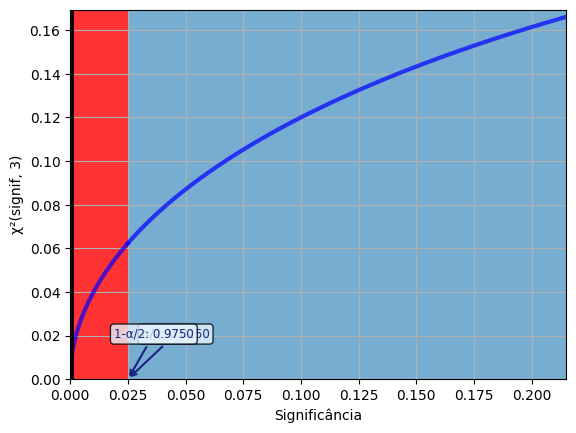

In [125]:
from scipy.stats import chi2
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

cmap_yellow_green_yellow = LinearSegmentedColormap.from_list(
    'yellow_green_yellow',
    ['yellow', 'green', 'yellow'],
    N=256
)

def grafico_teste_hipotesebicaudal(quicalc, signif, df):
    quimin = chi2.ppf(signif/2, gl)
    x = []
    # x.append(np.linspace(0, chi2.ppf(signif/2, df), 100))
    # x.append(np.linspace(chi2.ppf(signif/2, df), chi2.ppf(signif/2, df) + 0.2*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)), 100))
    # x.append(np.linspace(chi2.ppf(signif/2, df) + 0.2*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)),
    #                   chi2.ppf(signif/2, df) + 0.4*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)), 100))
    # x.append(np.linspace(chi2.ppf(signif/2, df) + 0.4*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)),
    #                   chi2.ppf(signif/2, df) + 0.6*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)), 100))
    # x.append(np.linspace(chi2.ppf(signif/2, df) + 0.6*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)),
    #                   chi2.ppf(signif/2, df) + 0.8*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)), 100))
    # x.append(np.linspace(chi2.ppf(signif/2, df) + 0.8*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)), chi2.ppf(1-(signif/2), df), 100))
    # x.append(np.linspace(chi2.ppf(1-(signif/2), df), chi2.ppf(0.99, df), 100))
    x.append(np.linspace(0, signif/2, 100))
    x.append(np.linspace(signif/2, signif/2 + 0.2*(1-(signif/2)-signif/2), 100))

    # x.append(np.linspace(chi2.ppf(signif/2, df) + 0.2*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)),
    #                   chi2.ppf(signif/2, df) + 0.4*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)), 100))
    # x.append(np.linspace(chi2.ppf(signif/2, df) + 0.4*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)),
    #                   chi2.ppf(signif/2, df) + 0.6*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)), 100))
    # x.append(np.linspace(chi2.ppf(signif/2, df) + 0.6*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)),
    #                   chi2.ppf(signif/2, df) + 0.8*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)), 100))
    # x.append(np.linspace(chi2.ppf(signif/2, df) + 0.8*(chi2.ppf(1-(signif/2), df)-chi2.ppf(signif/2, df)), chi2.ppf(1-(signif/2), df), 100))
    # x.append(np.linspace(chi2.ppf(1-(signif/2), df), chi2.ppf(0.99, df), 100))


    if df ==1:
        maxY = 2
    else:
        maxY = 1.02 * max(chi2.pdf(x[0], df).tolist() + chi2.pdf(x[1], df).tolist())
                            # + chi2.pdf(x[2], df).tolist() + 
                            # chi2.pdf(x[3], df).tolist() +
                            # chi2.pdf(x[4], df).tolist() + 
                            # chi2.pdf(x[5], df).tolist()
    fig, ax = plt.subplots(1, 1)
    ax.plot(x[0], chi2.pdf(x[0], df), 'b-', lw=3, alpha=0.7)
    ax.plot(x[1], chi2.pdf(x[1], df), 'b-', lw=3, alpha=0.7)
    # ax.plot(x[2], chi2.pdf(x[2], df), 'b-', lw=3, alpha=0.7)
    # ax.plot(x[3], chi2.pdf(x[3], df), 'b-', lw=3, alpha=0.7)
    # ax.plot(x[4], chi2.pdf(x[4], df), 'b-', lw=3, alpha=0.7)
    # ax.plot(x[5], chi2.pdf(x[5], df), 'b-', lw=3, alpha=0.7)
    # ax.plot(x[6], chi2.pdf(x[6], df), 'b-', lw=3, alpha=0.7)

    ax.fill_between(x[0], 0, maxY, facecolor='red', alpha=0.8)
    ax.fill_between(x[1], 0, maxY, cmap=cmap_yellow_green_yellow, alpha=0.6)
    # ax.fill_between(x[2], 0, maxY, facecolor='green', alpha=0.6)
    # ax.fill_between(x[2], 0, maxY, facecolor='yellow', alpha=0.6)
    # ax.fill_between(x[3], 0, maxY, facecolor='green', alpha=0.6)
    # ax.fill_between(x[4], 0, maxY, facecolor='green', alpha=0.6)
    # ax.fill_between(x[4], 0, maxY, facecolor='yellow', alpha=0.6)
    # ax.fill_between(x[5], 0, maxY, facecolor='yellow', alpha=0.6)
    # ax.fill_between(x[6], 0, maxY, facecolor='red', alpha=0.8)

    ax.annotate(f"α/2: {signif/2:.4f}",
                xy=(x[0][-1], 0),
                xytext=(x[0][-1] + 10, 30), textcoords='offset points',
                fontsize=8.5, color='#1a237e',
                arrowprops=dict(arrowstyle='->', color='#1a237e', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', alpha=0.8))
    ax.annotate(f"1-α/2: {1-signif/2:.4f}",
                xy=(x[-1][0], 0),
                xytext=(x[-1][0] - 10, 30), textcoords='offset points',
                fontsize=8.5, color='#1a237e',
                arrowprops=dict(arrowstyle='->', color='#1a237e', lw=1.5),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#E3F2FD', alpha=0.8))

    plt.axvline(quicalc, color='k', linewidth='2')

    if df ==1:
        limit = [0, 6, 0, maxY]
    else:
        limit = [0, x[-1][-1], 0, maxY]
    plt.axis(limit)
    plt.grid(True)
    plt.xlabel('Significância')
    plt.ylabel(f'χ²(signif, {df})')
    plt.show()

    # print(x[0], x[1], x[2], x[3], x[4], x[5], x[6])

## Teste estatístico
# graus de liberdade (gl = número de observações - número de parâmetros)
gl = L.shape[0] - A.shape[1]
# sigma posterioti = V'PV/gl
sigmaposteriori= (V.T @ P @ V).item() /gl
quicalc = sigmaposteriori*gl/sigmapriori
signif = 0.05
grafico_teste_hipotesebicaudal(quicalc, signif, gl)
# quimax = chi2.ppf(1-signif/2, gl)
# quimin = chi2.ppf(signif/2, gl)
# quiideal =  (quimax + quimin)/2

In [105]:
x[1]

array([12.59265409])

## Lista de exercícios complementares